In [2]:
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os
import scipy.io as sio
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

########################################################################check SF3 in large scale ####################################
def sliding_window(total_length, window_size, step=1):
    """
    生成正确的滑动窗口切片（从0开始计数）
    """
    slices = []
    for start in range(0, total_length - window_size + 1, step):
        end = start + window_size - 1  # 结束索引是包含的
        slices.append((start, end))
    return slices
    
# 
from tqdm import tqdm
def check_SF3_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF3_L_tb=0
    SF3_T_tb=0
    SF3_L_lr=0
    SF3_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF3_L_tb=SF3_L_tb+dv**3
        SF3_T_tb=SF3_T_tb+dv*(du**2)
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF3_L_lr=SF3_L_lr+du**3
        SF3_T_lr=SF3_T_lr+du*(dv**2)
    
    SF3_L_tb=np.nanmean(SF3_L_tb/len(slices))
    SF3_T_tb=np.nanmean(SF3_T_tb/len(slices))
    SF3_L_lr=np.nanmean(SF3_L_lr/len(slices))
    SF3_T_lr=np.nanmean(SF3_T_lr/len(slices))
    R=xscale*window_size
    SF3_check=(SF3_L_tb+SF3_T_tb+SF3_L_lr+SF3_T_lr)/2
    return SF3_check, SF3_L_tb, SF3_T_tb, SF3_L_lr, SF3_T_lr,R


def check_SF1_largescale(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF1_L_tb=0
    SF1_T_tb=0
    SF1_L_lr=0
    SF1_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF1_L_tb=SF1_L_tb+dv
        SF1_T_tb=SF1_T_tb+du
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF1_L_lr=SF1_L_lr+du
        SF1_T_lr=SF1_T_lr+dv
    
    SF1_L_tb=np.nanmean(SF1_L_tb/len(slices))
    SF1_T_tb=np.nanmean(SF1_T_tb/len(slices))
    SF1_L_lr=np.nanmean(SF1_L_lr/len(slices))
    SF1_T_lr=np.nanmean(SF1_T_lr/len(slices))
    R=xscale*window_size
    SF1_L_check=(SF1_L_tb+SF1_L_lr)/2
    SF1_T_check=(SF1_T_tb+SF1_T_lr)/2
    return SF1_L_check, SF1_T_check,R


def check_SF1_largescale_alltime(u,v,xscale,total_length,window_size):
    
    # total_length = 287
    # window_size = 287
    step = 1
    slices = sliding_window(total_length, window_size, step)
    
    du=0
    dv=0
    SF1_L_tb=0
    SF1_T_tb=0
    SF1_L_lr=0
    SF1_T_lr=0
    for ii in tqdm(range(len(slices))):
        # print(f'{slices[ii][0]}{slices[ii][1]}')
        du=u[:,slices[ii][1],:]-u[:,slices[ii][0],:]
        dv=v[:,slices[ii][1],:]-v[:,slices[ii][0],:]
        SF1_L_tb=SF1_L_tb+dv
        SF1_T_tb=SF1_T_tb+du
    
        du=u[:,:,slices[ii][1]]-u[:,:,slices[ii][0]]
        dv=v[:,:,slices[ii][1]]-v[:,:,slices[ii][0]]
        SF1_L_lr=SF1_L_lr+du
        SF1_T_lr=SF1_T_lr+dv
    
    SF1_L_tb=np.nanmean(SF1_L_tb/len(slices),axis=(1))
    SF1_T_tb=np.nanmean(SF1_T_tb/len(slices),axis=(1))
    SF1_L_lr=np.nanmean(SF1_L_lr/len(slices),axis=(1))
    SF1_T_lr=np.nanmean(SF1_T_lr/len(slices),axis=(1))
    R=xscale*window_size
    SF1_L_check=(SF1_L_tb+SF1_L_lr)/2
    SF1_T_check=(SF1_T_tb+SF1_T_lr)/2
    return SF1_L_check, SF1_T_check,R

# check HF SF3

In [78]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'niskin2km_500m_grd.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
xscale=np.mean([dx,dy])
R=xscale*287

/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc


In [79]:
u=u2rho_3d(np.squeeze(ds['u'].values))
v=v2rho_3d(np.squeeze(ds['v'].values))

In [54]:
HF_SF3=sio.loadmat('HF_Eulerian_SF3.mat')
# HF_SF3
r=np.squeeze(HF_SF3['r'])
SF3_L=np.nanmean(np.squeeze(HF_SF3['S3L1_alltime']),axis=0)
SF3_T=np.nanmean(np.squeeze(HF_SF3['S3T1_alltime']),axis=0)
SF3=SF3_L+SF3_T
SF3.shape

(202,)

### HF sf3/r plt

NameError: name 'SF3_L_lr' is not defined

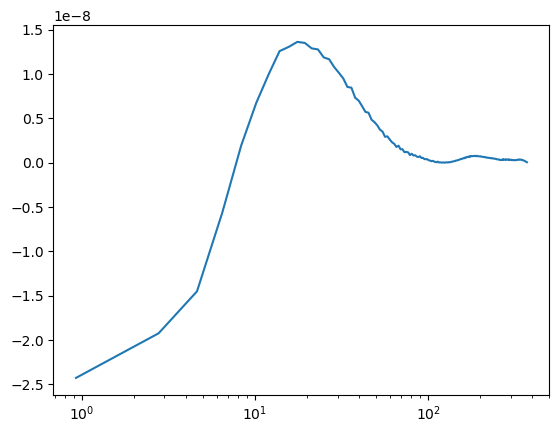

In [5]:
from matplotlib.gridspec import GridSpec
plt.semilogx(r/1e3,SF3/r,linewidth=1.5)
plt.semilogx(R/1e3,np.nanmean(SF3_L_lr+SF3_T_lr)/R,linewidth=1.5,marker='+')
plt.semilogx(R/1e3,np.nanmean(SF3_L_tb+SF3_T_tb)/R,linewidth=1.5,marker='+')

plt.grid(True)
plt.ylim([-1e-7,1e-7])

In [ ]:
Nlist=[10,20,50,100,150,200]
total_length=287
SF3_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    SF3_check[pos],  _, _, _, _,R_check[pos]=check_SF3_largescale(u,v,xscale,total_length,win)
    pos=pos+1

In [55]:
Nlist=([1,2,4,6,8,10,20,30,50,75,100,125,150,175,200])
total_length=287
SF1_L_check=np.zeros(len(Nlist))
SF1_T_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[int(pos)], SF1_T_check[int(pos)],R_check[int(pos)]=check_SF1_largescale(u,v,xscale,total_length,win)
    pos=pos+1

0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 287/287 [00:04<00:00, 68.94it/s]


1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:04<00:00, 58.62it/s]


2


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.07it/s]


13


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113/113 [00:02<00:00, 39.39it/s]


14


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:02<00:00, 40.60it/s]


In [80]:
total_length=287
SF1_L_check=np.zeros((2148,len(Nlist)))
SF1_T_check=np.zeros((2148,len(Nlist)))
# R_check=np.zeros((199,len(Nlist)))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[:,int(pos)], SF1_T_check[:,int(pos)],_=check_SF1_largescale_alltime(u,v,xscale,total_length,win)
    pos=pos+1

0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 287/287 [00:05<00:00, 56.76it/s]


1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:04<00:00, 58.84it/s]


2


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:03<00:00, 42.53it/s]


13


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113/113 [00:02<00:00, 42.27it/s]


14


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:02<00:00, 42.74it/s]


/tmp/ipykernel_2066909/1543609211.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, _ = pearsonr(sf1l_valid, sf1t_valid)


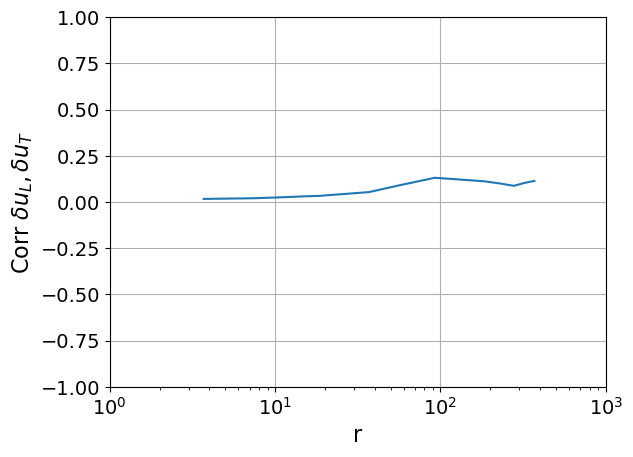

In [82]:
corr=temporal_correlation_per_scale(SF1_L_check, SF1_T_check)

plt.semilogx(R_check/1e3,corr)
plt.ylim(([-1,1]))
plt.xlim(([1e0,1e3]))
plt.grid(True)
plt.ylabel(r'Corr $\delta u_{L}, \delta u_{T}$')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_homogeneity.png', dpi=300, bbox_inches='tight')
plt.xlabel(r'r')
sio.savemat('/meddy/simingzhang/Data/Figure_SF3/HF_isotropic.mat',{'R_check':R_check,'corr_e_hf':corr,'corr_e_sm':corr_e_sm})

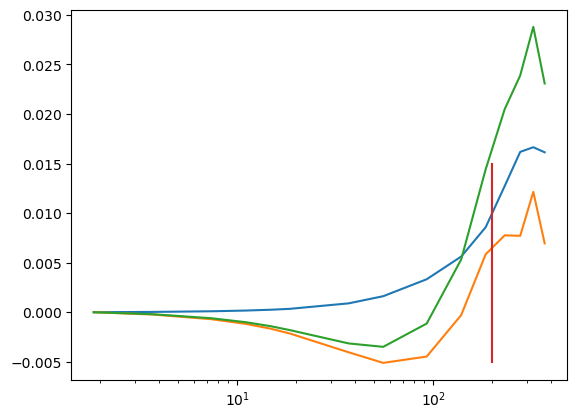

In [7]:
plt.semilogx(R_check/1e3,SF1_L_check,'')
plt.semilogx(R_check/1e3,SF1_T_check)
plt.semilogx(R_check/1e3,(SF1_T_check+SF1_L_check))
plt.plot([200,200],[-0.005,0.015])

In [8]:
SF1=SF1_T_check+SF1_L_check
sio.savemat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_Hf.mat',{'SF1':SF1,'R_check':R_check})

In [ ]:
SF3_check.shape

Text(0.5, 1.0, 'Wave case: SF3/r')

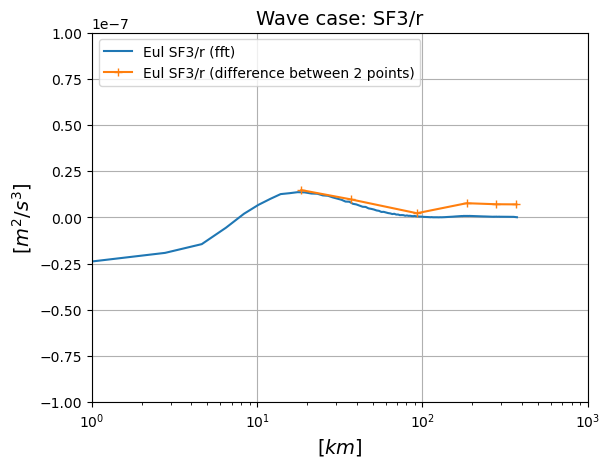

In [130]:
from matplotlib.gridspec import GridSpec
plt.semilogx(r/1e3,SF3/r,linewidth=1.5,label='Eul SF3/r (fft)')
plt.semilogx(R_check/1e3,SF3_check/R_check,linewidth=1.5,marker='+',label='Eul SF3/r (difference between 2 points)')
plt.grid(True)
plt.legend(loc=2)
plt.ylim([-1e-7,1e-7])
plt.xlim([1,1e3])
plt.xlabel('$[km]$',fontsize=14)
plt.ylabel('$[m^{2}/s^{3}]$',fontsize=14)
plt.title('Wave case: SF3/r',fontsize=14)

In [ ]:
sio.savemat('HF_SF3_check.mat',{'R_check':R_check,'SF3_check':SF3_check})

# SM

In [62]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='iceland_no_wave/z_niskin2km_his_smooth_depth_500m_grd.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'niskin2km_500m_grd.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
xscale=np.mean([dx,dy])
R=xscale*287

u=u2rho_3d(np.squeeze(ds['u'].values))
v=v2rho_3d(np.squeeze(ds['v'].values))

SM_SF3=sio.loadmat('SM_Eulerian_SF3.mat')
# SM_SF3
r=np.squeeze(SM_SF3['r'])
SF3_L=np.nanmean(np.squeeze(SM_SF3['S3L1_alltime']),axis=0)
SF3_T=np.nanmean(np.squeeze(SM_SF3['S3T1_alltime']),axis=0)
SF3=SF3_L+SF3_T
SF3.shape

Nlist=[10,20,50,100,150,200]
total_length=287
SF3_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    SF3_check[pos],  _, _, _, _,R_check[pos]=check_SF3_largescale(u,v,xscale,total_length,win)
    pos=pos+1

/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/z_niskin2km_his_smooth_depth_500m_grd.0002.nc


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:08<00:00, 10.41it/s]


In [63]:
Nlist=([1,2,4,6,8,10,20,30,50,75,100,125,150,175,200])
total_length=287
SF1_L_check=np.zeros(len(Nlist))
SF1_T_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[int(pos)], SF1_T_check[int(pos)],R_check[int(pos)]=check_SF1_largescale(u,v,xscale,total_length,win)
    pos=pos+1

SF1=SF1_T_check+SF1_L_check
sio.savemat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_Sm.mat',{'SF1':SF1,'R_check':R_check})

0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 287/287 [00:06<00:00, 43.39it/s]


1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:06<00:00, 45.10it/s]


2


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:05<00:00, 26.33it/s]


13


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113/113 [00:04<00:00, 26.74it/s]


14


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 24.50it/s]


In [64]:
total_length=287
SF1_L_check=np.zeros((2148,len(Nlist)))
SF1_T_check=np.zeros((2148,len(Nlist)))
# R_check=np.zeros((199,len(Nlist)))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[:,int(pos)], SF1_T_check[:,int(pos)],_=check_SF1_largescale_alltime(u,v,xscale,total_length,win)
    pos=pos+1

0


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 287/287 [00:06<00:00, 43.54it/s]


1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 286/286 [00:07<00:00, 38.43it/s]


2


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 138/138 [00:05<00:00, 27.12it/s]


13


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 113/113 [00:03<00:00, 34.73it/s]


14


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 28.82it/s]


In [65]:
corr_e_sm=temporal_correlation_per_scale(SF1_L_check, SF1_T_check)


/tmp/ipykernel_2066909/1543609211.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, _ = pearsonr(sf1l_valid, sf1t_valid)


Text(0.5, 1.0, 'Nowave case: SF3/r')

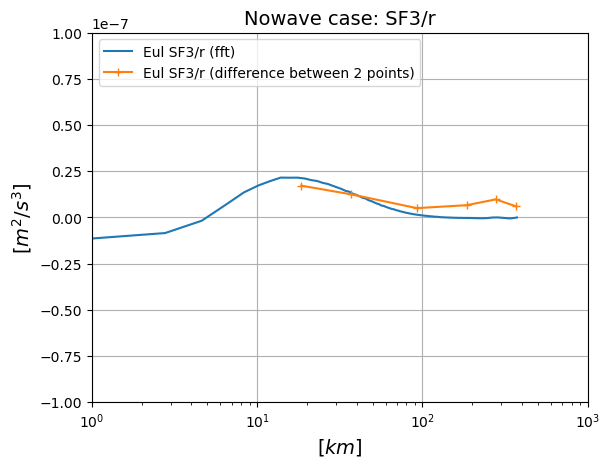

In [133]:
from matplotlib.gridspec import GridSpec
plt.semilogx(r/1e3,SF3/r,linewidth=1.5,label='Eul SF3/r (fft)')
plt.semilogx(R_check/1e3,SF3_check/R_check,linewidth=1.5,marker='+',label='Eul SF3/r (difference between 2 points)')
plt.grid(True)
plt.legend(loc=2)
plt.ylim([-1e-7,1e-7])
plt.xlim([1,1e3])
plt.xlabel('$[km]$',fontsize=14)
plt.ylabel('$[m^{2}/s^{3}]$',fontsize=14)
plt.title('Nowave case: SF3/r',fontsize=14)

In [135]:
sio.savemat('SM_SF3_check.mat',{'R_check':R_check,'SF3_check':SF3_check})

# HIT2d

In [14]:
data_dir='/meddy/simingzhang/Data/Parcels_data/'
fname='HIT2dcase_modified_cg_nowin.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
files=data_dir+fname
print(files)
ds=xr.open_dataset(files)
ds

grid=xr.open_dataset(data_dir+'HIT2dcase_modified_cg_nowin.nc')
dx=1/grid['pm'].values
dy=1/grid['pn'].values
xscale=np.mean([dx,dy])
R=xscale*512

u=u2rho_3d(np.squeeze(ds['u'].values))
v=v2rho_3d(np.squeeze(ds['v'].values))


data=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/HIT2d_Eulerian_SF3.mat')
# SM_SF3
r=np.squeeze(data['r'])
SF3_L=np.nanmean(np.squeeze(data['S3L1_time']),axis=0)
SF3_T=np.nanmean(np.squeeze(data['S3T1_time']),axis=0)
SF3=SF3_L+SF3_T
SF3.shape

/meddy/simingzhang/Data/Parcels_data/HIT2dcase_modified_cg_nowin.nc


/tmp/ipykernel_2066909/4098906335.py:22: RuntimeWarning: Mean of empty slice
  SF3_L=np.nanmean(np.squeeze(data['S3L1_time']),axis=0)
/tmp/ipykernel_2066909/4098906335.py:23: RuntimeWarning: Mean of empty slice
  SF3_T=np.nanmean(np.squeeze(data['S3T1_time']),axis=0)


(362,)

### sf3

In [15]:
Nlist=[10,20,50,100,150,200]
total_length=512
SF3_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    SF3_check[pos],  _, _, _, _,R_check[pos]=check_SF3_largescale(u,v,xscale,total_length,win)
    pos=pos+1

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 313/313 [00:04<00:00, 74.18it/s]


### sf1 (homogenenity)

In [35]:
Nlist=([1,2,4,6,8,10,20,30,50,75,100,125,150,175,200,225,250,275,300,325,350,375,400,425,450,475,500])
total_length=512
SF1_L_check=np.zeros(len(Nlist))
SF1_T_check=np.zeros(len(Nlist))
R_check=np.zeros(len(Nlist))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[int(pos)], SF1_T_check[int(pos)],R_check[int(pos)]=check_SF1_largescale(u,v,xscale,total_length,win)
    pos=pos+1

SF1=SF1_T_check+SF1_L_check
sio.savemat('/meddy/simingzhang/Data/Figure_SF3/SF1_E_hit.mat',{'SF1':SF1,'R_check':R_check})

0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 512/512 [00:01<00:00, 482.58it/s]


1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 511/511 [00:01<00:00, 490.52it/s]


2


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:00<00:00, 343.65it/s]


25


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:00<00:00, 321.66it/s]


26


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 328.38it/s]


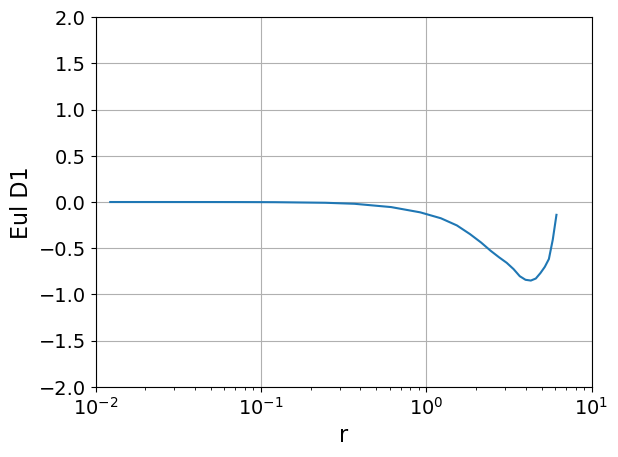

In [17]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
plt.semilogx(R_check,SF1)
plt.ylim(([-2,2]))
plt.xlim(([1e-2,1e1]))
plt.grid(True)
plt.ylabel(r'Eul D1')
plt.xlabel(r'r')
# plt.title(r'HIT2d')
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_homogeneity.png', dpi=300, bbox_inches='tight')

In [13]:
0.0123*100

1.23

In [22]:
np.mean(u),np.mean(v)

(2.0223911880734637e-17, -1.253055423830118e-18)

In [7]:
SF1.shape

(27,)

/tmp/ipykernel_2066909/3135430756.py:1: RuntimeWarning: invalid value encountered in divide
  plt.semilogx(R_check,np.abs(SF1_L_check/SF1_T_check))


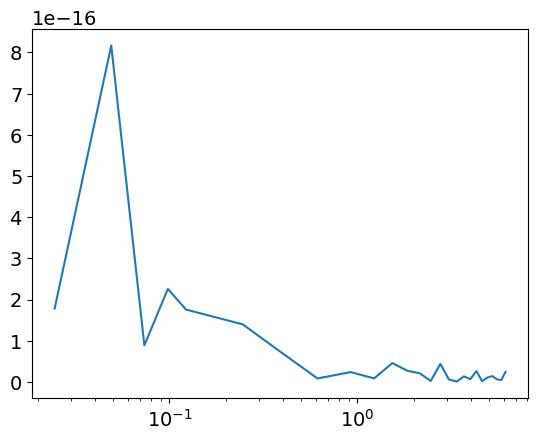

In [9]:
plt.semilogx(R_check,np.abs(SF1_L_check/SF1_T_check))

In [10]:
def data_driven_correlation_test(SF1l, SF1t):
    """基于数据本身的相关性检验"""
    
    # 移除NaN值
    valid_mask = ~(np.isnan(SF1l) | np.isnan(SF1t))
    SF1l_clean = SF1l[valid_mask]
    SF1t_clean = SF1t[valid_mask]
    
    if len(SF1l_clean) < 3:
        return {'valid': False, 'reason': '样本不足'}
    
    # 计算Pearson相关系数
    correlation_R = np.corrcoef(SF1l_clean, SF1t_clean)[0, 1]
    
    # 计算Spearman秩相关（对非线性更鲁棒）
    from scipy.stats import spearmanr
    spearman_rho, spearman_p = spearmanr(SF1l_clean, SF1t_clean)
    
    # 判断标准（基于数据本身，不预设理论）
    if correlation_R > 0.8 and spearman_rho > 0.7:
        relationship_strength = "强相关"
    elif correlation_R > 0.6 and spearman_rho > 0.5:
        relationship_strength = "中等相关"
    else:
        relationship_strength = "弱相关或无相关"
    
    return {
        'pearson_R': correlation_R,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p,
        'sample_size': len(SF1l_clean),
        'relationship': relationship_strength,
        'interpretation': f"纵向和横向结构函数显示{relationship_strength}"
    }

In [11]:
data_driven_correlation_test(SF1_L_check, SF1_T_check)

{'pearson_R': 0.09029683383857295,
 'spearman_rho': 0.2551892551892551,
 'spearman_p': 0.19891378571340063,
 'sample_size': 27,
 'relationship': '弱相关或无相关',
 'interpretation': '纵向和横向结构函数显示弱相关或无相关'}

In [36]:
Nlist=([1,2,4,6,8,10,20,30,50,75,100,125,150,175,200,225,250,275,300,325,350,375,400,425,450,475,500])
total_length=512
SF1_L_check=np.zeros((199,len(Nlist)))
SF1_T_check=np.zeros((199,len(Nlist)))
# R_check=np.zeros((199,len(Nlist)))
pos=0

for win in (Nlist):
    # print(win)
    print(f'{pos}')
    SF1_L_check[:,int(pos)], SF1_T_check[:,int(pos)],_=check_SF1_largescale_alltime(u,v,xscale,total_length,win)
    pos=pos+1

# SF1=SF1_T_check+SF1_L_check

0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 512/512 [00:00<00:00, 573.92it/s]


1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 511/511 [00:00<00:00, 511.38it/s]


2


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:00<00:00, 331.59it/s]


25


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:00<00:00, 314.62it/s]


26


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 320.11it/s]


In [22]:
SF1_L_check.shape

(199, 27)

In [23]:
def temporal_correlation_per_scale(SF1l, SF1t):
    """
    对每个尺度独立计算SF1l和SF1t的时间序列相关性
    输入: SF1l, SF1t - 形状为 (n_time, n_scales) 的数组
    输出: 每个尺度的Pearson相关系数数组
    """
    import numpy as np
    from scipy.stats import pearsonr
    
    n_time, n_scales = SF1l.shape
    correlation_by_scale = np.full(n_scales, np.nan)
    
    for scale_idx in range(n_scales):
        # 提取该尺度的时间序列
        sf1l_ts = SF1l[:, scale_idx]
        sf1t_ts = SF1t[:, scale_idx]
        
        # 移除NaN值
        valid_mask = ~(np.isnan(sf1l_ts) | np.isnan(sf1t_ts))
        sf1l_valid = sf1l_ts[valid_mask]
        sf1t_valid = sf1t_ts[valid_mask]
        
        # 确保有足够样本
        if len(sf1l_valid) >= 3:
            try:
                r_value, _ = pearsonr(sf1l_valid, sf1t_valid)
                correlation_by_scale[scale_idx] = r_value
            except:
                correlation_by_scale[scale_idx] = np.nan
    
    return correlation_by_scale

In [24]:
corr=temporal_correlation_per_scale(SF1_L_check, SF1_T_check)

/tmp/ipykernel_2066909/1543609211.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_value, _ = pearsonr(sf1l_valid, sf1t_valid)


Text(0.5, 0, 'r')

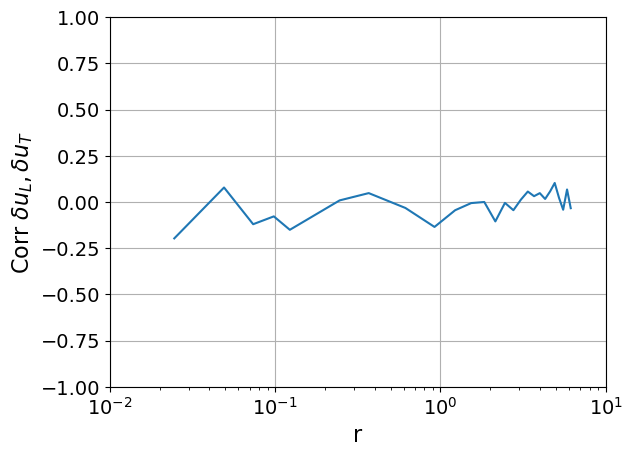

In [40]:
plt.semilogx(R_check,corr)
plt.ylim(([-1,1]))
plt.xlim(([1e-2,1e1]))
plt.grid(True)
plt.ylabel(r'Corr $\delta u_{L}, \delta u_{T}$')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_homogeneity.png', dpi=300, bbox_inches='tight')
plt.xlabel(r'r')

In [47]:
data=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T150timeavg2_sf1.mat')
sf1l=data['SF1l_time'].T
sf1t=data['SF1t_time'].T
dist_axis=np.squeeze(data['dist_axis'])

In [45]:
corr_L=temporal_correlation_per_scale(sf1l, sf1t)

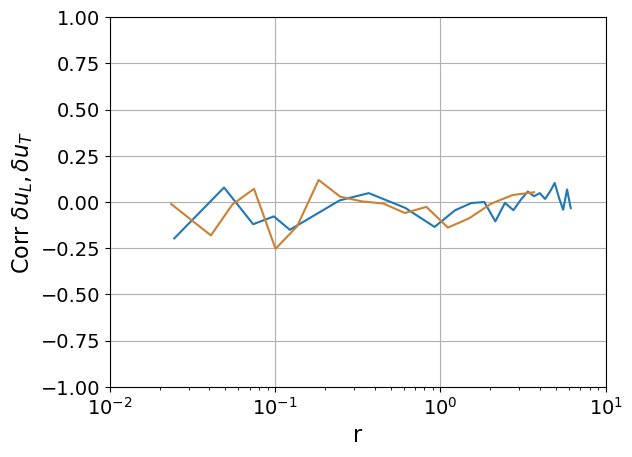

In [51]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
plt.semilogx(R_check,corr)
plt.semilogx(dist_axis,corr_L,color=(0.8, 0.5, 0.2))
plt.ylim(([-1,1]))
plt.xlim(([1e-2,1e1]))
plt.grid(True)
plt.ylabel(r'Corr $\delta u_{L}, \delta u_{T}$')
plt.xlabel(r'r')
plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_isotropic.png', dpi=300, bbox_inches='tight')


# plot corr

In [6]:
data1=sio.loadmat('/meddy/simingzhang/Data/Figure_SF3/HF_isotropic.mat')

In [7]:
corr_e_hf=np.squeeze(data1['corr_e_hf'])
corr_e_sm=np.squeeze(data1['corr_e_sm'])
R_check=np.squeeze(data1['R_check'])


Text(0.5, 0, 'r')

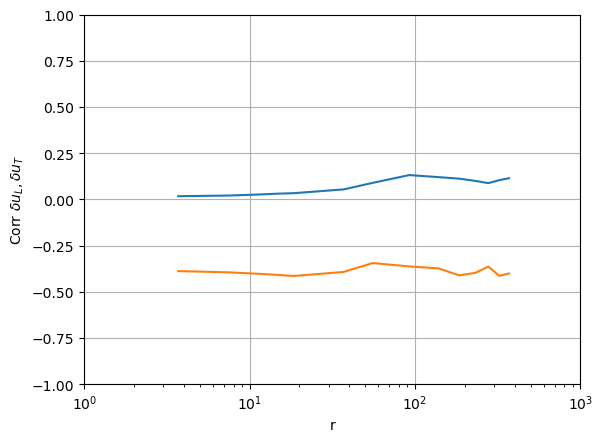

In [8]:
plt.semilogx(R_check/1e3,corr_e_hf)
plt.semilogx(R_check/1e3,corr_e_sm)
plt.ylim([-1,1])
plt.xlim(([1e0,1e3]))
plt.grid(True)
plt.ylabel(r'Corr $\delta u_{L}, \delta u_{T}$')
# plt.savefig(f'/meddy/simingzhang/Data/Figure_SF3/hit2d_homogeneity.png', dpi=300, bbox_inches='tight')
plt.xlabel(r'r')

In [86]:
# w_sf1_289=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P289T1940_roughbootstrap_SF1.mat')
# w_SF1_289=np.squeeze(w_sf1_289['SF1'])
# w_sf1_625=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P625T1940_roughbootstrap_SF1.mat')
# w_SF1_625=np.squeeze(w_sf1_625['SF1'])
# w_sf1_1089=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T1940_roughbootstrap_SF1.mat')
# w_SF1_1089=np.squeeze(w_sf1_1089['SF1'])

# nw_sf1_289=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P289T1940_roughbootstrap_SF1.mat')
# nw_SF1_289=np.squeeze(nw_sf1_289['SF1'])
# nw_sf1_625=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P625T1940_roughbootstrap_SF1.mat')
# nw_SF1_625=np.squeeze(nw_sf1_625['SF1'])
# nw_sf1_1089=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/nowave_pars_P1089T1940_roughbootstrap_SF1.mat')
# nw_SF1_1089=np.squeeze(nw_sf1_1089['SF1'])


# w_sf1_289s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P289T1940_roughsmallbootstrap_SF1.mat')
# w_SF1_289s=np.squeeze(w_sf1_289s['SF1'])
# w_sf1_625s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P625T1940_roughsmallbootstrap_SF1.mat')
# w_SF1_625s=np.squeeze(w_sf1_625s['SF1'])
# w_sf1_1089s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/wave_pars_P1089T1940_roughsmallbootstrap_SF1.mat')
# w_SF1_1089s=np.squeeze(w_sf1_1089s['SF1'])

# nw_sf1_289s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T1940_roughsmallbootstrap_SF1.mat')
# nw_SF1_289s=np.squeeze(nw_sf1_289s['SF1'])
# nw_sf1_625s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P625T1940_roughsmallbootstrap_SF1.mat')
# nw_SF1_625s=np.squeeze(nw_sf1_625s['SF1'])
# nw_sf1_1089s=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P1089T1940_roughsmallbootstrap_SF1.mat')
# nw_SF1_1089s=np.squeeze(nw_sf1_1089s['SF1'])

AttributeError: 'dict' object has no attribute 'shape'